# Transaction Anomaly & Fraud Risk Detection

**Objective:** Build an explainable, end-to-end risk scoring pipeline that flags suspicious credit card transactions — simulating how fraud operations teams prioritize investigations in a banking environment.

**Approach:**
1. Engineer behavioral risk signals from raw transaction data
2. Build a transparent rule-based composite risk score
3. Layer in an unsupervised Isolation Forest model for continuous risk scoring
4. Validate all outputs against actual fraud labels
5. Export a scored dataset for Power BI dashboard consumption

**Dataset:** ~1.3M synthetic credit card transactions with fraud labels (for validation only — not used in model training)

---
## 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.ensemble import IsolationForest

pd.set_option('display.float_format', '{:.2f}'.format)
print('Libraries loaded successfully')

Libraries loaded successfully


---
## 2. Load & Explore Data

We begin by loading the raw transaction data and performing an initial quality check.

> **Note:** Update the file path below to match your local directory before running.

In [2]:
# Dataset: publicly available synthetic credit card transaction dataset
# Place transactions.csv in a data/ folder at the repo root before running

import os
# Resolve path relative to notebook location so it works on any machine
BASE_DIR  = os.path.dirname(os.path.abspath('__file__'))
FILE_PATH = os.path.join(BASE_DIR, '..', 'data', 'transactions.csv')

df = pd.read_csv(FILE_PATH, index_col=0)
print(f'Dataset shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
df.head()


Dataset shape: (1296675, 23)
Columns: ['trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip', 'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time', 'merch_lat', 'merch_long', 'is_fraud', 'merch_zipcode']


,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,merch_zipcode
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,...,-81.18,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.01,-82.05,0,28705.00
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,...,-118.21,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.16,-118.19,0,NaN
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,...,-112.26,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.15,-112.15,0,83236.00
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,...,-112.11,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.03,-112.56,0,NaN
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,...,-79.46,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.67,-78.63,0,22844.00


In [3]:
# Data quality check
print('--- Data Types ---')
print(df.dtypes)
print('\n--- Missing Values ---')
print(df.isna().sum().sort_values(ascending=False))

--- Data Types ---
trans_date_trans_time     object
cc_num                     int64
merchant                  object
category                  object
amt                      float64
first                     object
last                      object
gender                    object
street                    object
city                      object
state                     object
zip                        int64
lat                      float64
long                     float64
city_pop                   int64
job                       object
dob                       object
trans_num                 object
unix_time                  int64
merch_lat                float64
merch_long               float64
is_fraud                   int64
merch_zipcode            float64
dtype: object

--- Missing Values ---
merch_zipcode            195973
lat                           0
is_fraud                      0
merch_long                    0
merch_lat                     0
unix_time               

In [4]:

fraud_counts = df['is_fraud'].value_counts()
fraud_rate = df['is_fraud'].mean() * 100

print('--- Fraud Distribution ---')
print(fraud_counts)
print(f'\nOverall fraud rate: {fraud_rate:.2f}%')
print('\nNote: Dataset is heavily imbalanced — this is typical in fraud detection.')
print('Fraud labels are used ONLY for validation, not model training.')

--- Fraud Distribution ---
is_fraud
0    1289169
1       7506
Name: count, dtype: int64

Overall fraud rate: 0.58%

Note: Dataset is heavily imbalanced — this is typical in fraud detection.
Fraud labels are used ONLY for validation, not model training.


In [5]:

print('--- Transaction Amount Distribution ---')
print(df['amt'].describe())

print(f"\nAvg amount (legitimate): ${df[df['is_fraud']==0]['amt'].mean():.2f}")
print(f"Avg amount (fraudulent): ${df[df['is_fraud']==1]['amt'].mean():.2f}")

--- Transaction Amount Distribution ---
count   1296675.00
mean         70.35
std         160.32
min           1.00
25%           9.65
50%          47.52
75%          83.14
max       28948.90
Name: amt, dtype: float64

Avg amount (legitimate): $67.67
Avg amount (fraudulent): $531.32


---
## 3. Feature Engineering

We extract time-based features from the transaction timestamp and compute behavioral aggregates.

**Features created:**
- `txn_hour` — hour of day (0–23), used to detect late-night transactions
- `txn_day` — day of week (0=Monday), used as a behavioral pattern feature
- `amt_zscore` — standardized transaction amount (how far from the mean)
- `txn_count_per_card` — total transactions per card, captures velocity
- `txn_count_per_merchant` — total transactions per merchant

In [6]:

df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
df['txn_hour'] = df['trans_date_trans_time'].dt.hour
df['txn_day']  = df['trans_date_trans_time'].dt.dayofweek

print('Time features created.')
print(df[['trans_date_trans_time', 'txn_hour', 'txn_day']].head())

Time features created.
           trans_date_trans_time  txn_hour  txn_day
Unnamed: 0                                         
0            2019-01-01 00:00:18         0        1
1            2019-01-01 00:00:44         0        1
2            2019-01-01 00:00:51         0        1
3            2019-01-01 00:01:16         0        1
4            2019-01-01 00:03:06         0        1


In [7]:

df['amt_zscore'] = (df['amt'] - df['amt'].mean()) / df['amt'].std()

# Velocity features — how active is this card / merchant?
df['txn_count_per_card']     = df.groupby('cc_num')['amt'].transform('count')
df['txn_count_per_merchant'] = df.groupby('merchant')['amt'].transform('count')

print('Behavioral features created.')
print(df[['amt', 'amt_zscore', 'txn_count_per_card', 'txn_count_per_merchant']].head())

Behavioral features created.
              amt  amt_zscore  txn_count_per_card  txn_count_per_merchant
Unnamed: 0                                                               
0            4.97       -0.41                2028                    1267
1          107.23        0.23                3030                    2503
2          220.11        0.93                 503                    1895
3           45.00       -0.16                 493                    2613
4           41.96       -0.18                2017                    1592


---
## 4. Rule-Based Risk Scoring

Before applying machine learning, we engineer two explainable risk signals grounded in domain knowledge:

1. **High amount flag** — transactions in the top 5% by amount. High-value transactions are a well-known fraud vector.
2. **Odd hour flag** — transactions between 10 PM and 3 AM. Fraudsters often operate when cardholders are asleep and less likely to notice.

These signals are combined into a **composite rule risk score (0–2)**. This approach prioritises interpretability — a requirement in regulated banking environments where every flag must be explainable to compliance teams.

We then **validate each signal against actual fraud labels** to confirm they have genuine predictive value.

In [8]:

HIGH_AMT_THRESHOLD = df['amt'].quantile(0.95)
print(f'High amount threshold (95th pct): ${HIGH_AMT_THRESHOLD:.2f}')

df['high_amount_flag'] = (df['amt'] > HIGH_AMT_THRESHOLD).astype(int)

fraud_above = df[df['high_amount_flag']==1]['is_fraud'].mean() * 100
fraud_below = df[df['high_amount_flag']==0]['is_fraud'].mean() * 100
print(f'\nFraud rate above threshold: {fraud_above:.2f}%')
print(f'Fraud rate below threshold: {fraud_below:.2f}%')
print(f'Lift: {fraud_above/fraud_below:.1f}x')

High amount threshold (95th pct): $196.31

Fraud rate above threshold: 8.80%
Fraud rate below threshold: 0.15%
Lift: 60.2x


In [9]:

df['odd_hour_flag'] = df['txn_hour'].apply(
    lambda h: 1 if (h >= 22 or h <= 3) else 0
)

# Validate: fraud rate by hour
hourly_fraud = df.groupby('txn_hour')['is_fraud'].mean() * 100
print('Fraud rate by hour (%):')
print(hourly_fraud.round(2))

Fraud rate by hour (%):
txn_hour
0    1.49
1    1.53
2    1.47
3    1.42
4    0.11
5    0.14
6    0.09
7    0.13
8    0.12
9    0.11
10   0.09
11   0.10
12   0.10
13   0.12
14   0.13
15   0.12
16   0.12
17   0.12
18   0.12
19   0.12
20   0.10
21   0.11
22   2.88
23   2.84
Name: is_fraud, dtype: float64


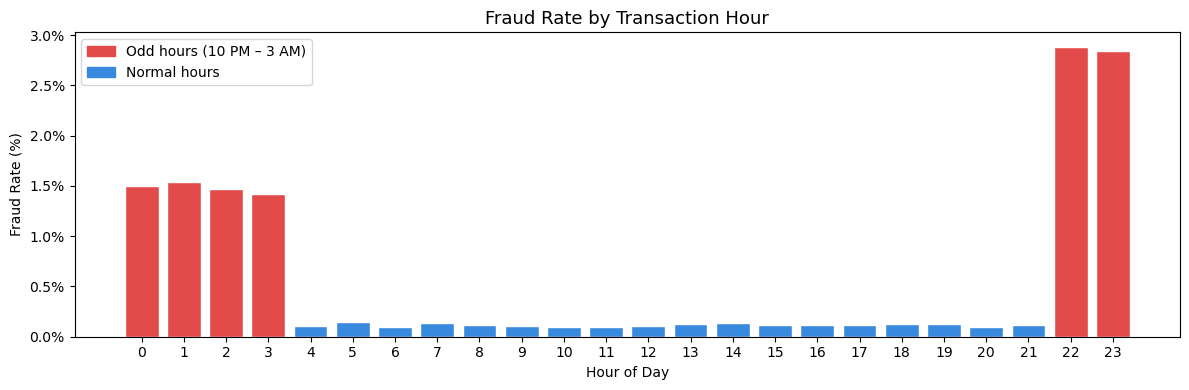

In [10]:
# Visualise: fraud rate by hour
fig, ax = plt.subplots(figsize=(12, 4))
colors = ['#E24B4A' if (h >= 22 or h <= 3) else '#378ADD' for h in hourly_fraud.index]
ax.bar(hourly_fraud.index, hourly_fraud.values, color=colors, edgecolor='white')
ax.set_title('Fraud Rate by Transaction Hour', fontsize=13)
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Fraud Rate (%)')
ax.set_xticks(range(24))
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))
# Legend
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color='#E24B4A', label='Odd hours (10 PM – 3 AM)'),
    Patch(color='#378ADD', label='Normal hours')
], fontsize=10)
plt.tight_layout()
plt.show()

In [11]:

df['rule_risk_score'] = df['high_amount_flag'] + df['odd_hour_flag']

print('Rule risk score distribution:')
print(df['rule_risk_score'].value_counts().sort_index())

Rule risk score distribution:
rule_risk_score
0    945858
1    331930
2     18887
Name: count, dtype: int64


In [12]:

validation = df.groupby('rule_risk_score')['is_fraud'].agg(
    total_txns='count',
    fraud_cases='sum',
    fraud_rate_pct=lambda x: round(x.mean() * 100, 2)
).reset_index()

print('--- Rule Risk Score Validation ---')
print(validation)
print('\nKey insight: Score-2 bucket (both flags) has a {:.1f}x higher fraud rate than score-0'.format(
    validation.loc[2, 'fraud_rate_pct'] / validation.loc[0, 'fraud_rate_pct']
))

--- Rule Risk Score Validation ---
   rule_risk_score  total_txns  fraud_cases  fraud_rate_pct
0                0      945858          282            0.03
1                1      331930         2381            0.72
2                2       18887         4843           25.64

Key insight: Score-2 bucket (both flags) has a 854.7x higher fraud rate than score-0


---
## 5. Isolation Forest — Unsupervised Anomaly Detection

The rule-based score is interpretable but limited to two signals. We now layer in an **Isolation Forest**, an unsupervised anomaly detection algorithm that scores transactions based on how easy they are to isolate from the rest of the data.

**Key design decisions:**
- **No fraud labels used** — the model learns what 'normal' looks like from the data itself
- **Contamination = 0.006** — aligned to the observed fraud rate (~0.58%), keeping the anomaly flag precise
- **5 features** — amount, time signals, and rule-based flags as combined inputs
- **200 estimators** — enough trees for stable, consistent scoring on 1.3M rows

The raw Isolation Forest score is then **normalised to a 0–100 scale** for easy interpretation in dashboards.

In [13]:
# Feature matrix for Isolation Forest
FEATURES = ['amt', 'txn_hour', 'txn_day', 'high_amount_flag', 'odd_hour_flag']
X = df[FEATURES].fillna(0)
print(f'Feature matrix shape: {X.shape}')
print(f'Features used: {FEATURES}')

Feature matrix shape: (1296675, 5)
Features used: ['amt', 'txn_hour', 'txn_day', 'high_amount_flag', 'odd_hour_flag']


In [14]:

iso = IsolationForest(
    n_estimators=200,
    contamination=0.006,
    random_state=42
)
iso.fit(X)

# Binary anomaly flag: 1 = anomalous, 0 = normal
df['anomaly_flag'] = (iso.predict(X) == -1).astype(int)

print('Anomaly flag distribution:')
print(df['anomaly_flag'].value_counts())

Anomaly flag distribution:
anomaly_flag
0    1288894
1       7781
Name: count, dtype: int64


In [15]:

raw_score = -iso.decision_function(X)  # invert so higher = riskier
df['iso_score_scaled'] = (
    100 * (raw_score - raw_score.min()) /
    (raw_score.max() - raw_score.min())
)

print('ISO score summary:')
print(df['iso_score_scaled'].describe())

ISO score summary:
count   1296675.00
mean         20.80
std          17.61
min           0.00
25%           8.04
50%          13.87
75%          32.84
max         100.00
Name: iso_score_scaled, dtype: float64


In [16]:

print('Average risk score by fraud label:')
print(df.groupby('is_fraud')['iso_score_scaled'].mean().rename(
    index={0: 'Legitimate', 1: 'Fraudulent'}
).round(2))

print('\nFraud breakdown at risk score > 90:')
high_risk = df[df['iso_score_scaled'] > 90]['is_fraud'].value_counts()
precision = high_risk.get(1, 0) / high_risk.sum() * 100
print(high_risk.rename(index={0: 'Legitimate', 1: 'Fraudulent'}))
print(f'\nPrecision at score > 90: {precision:.1f}%')

Average risk score by fraud label:
is_fraud
Legitimate   20.50
Fraudulent   73.42
Name: iso_score_scaled, dtype: float64

Fraud breakdown at risk score > 90:
is_fraud
Fraudulent    2354
Legitimate    1643
Name: count, dtype: int64

Precision at score > 90: 58.9%


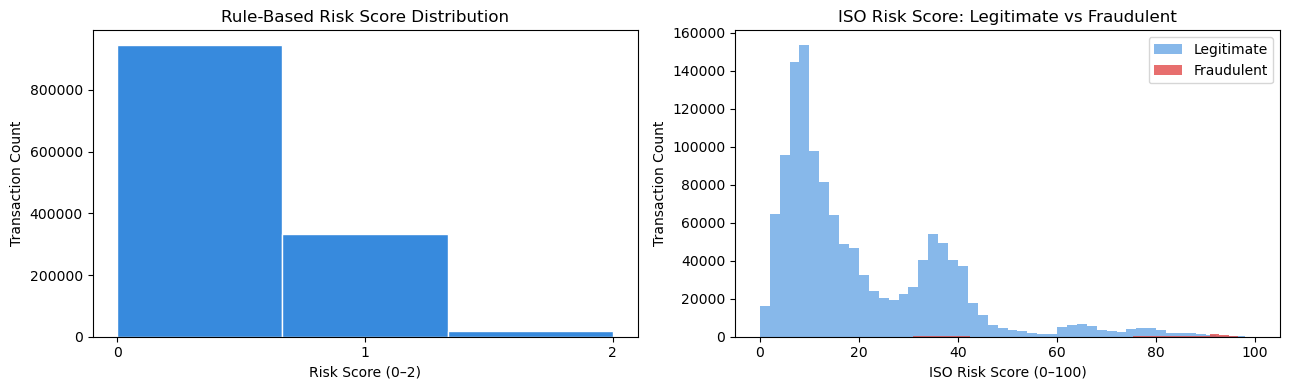

In [17]:

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: rule risk score distribution
axes[0].hist(df['rule_risk_score'], bins=3, color='#378ADD', edgecolor='white')
axes[0].set_title('Rule-Based Risk Score Distribution')
axes[0].set_xlabel('Risk Score (0–2)')
axes[0].set_ylabel('Transaction Count')
axes[0].set_xticks([0, 1, 2])

# Right: ISO score by fraud label
axes[1].hist(
    df[df['is_fraud']==0]['iso_score_scaled'],
    bins=50, alpha=0.6, color='#378ADD', label='Legitimate'
)
axes[1].hist(
    df[df['is_fraud']==1]['iso_score_scaled'],
    bins=50, alpha=0.8, color='#E24B4A', label='Fraudulent'
)
axes[1].set_title('ISO Risk Score: Legitimate vs Fraudulent')
axes[1].set_xlabel('ISO Risk Score (0–100)')
axes[1].set_ylabel('Transaction Count')
axes[1].legend()

plt.tight_layout()
plt.show()

---
## 6. Final Output & Export

We compile the final scored dataset for export to Power BI.

**Output columns:**
- `rule_risk_score` — transparent composite score (0, 1, or 2)
- `iso_score_scaled` — continuous anomaly score (0–100)
- `anomaly_flag` — binary Isolation Forest flag
- `is_fraud` — ground truth label (for dashboard validation visuals)
- `amt`, `category`, `txn_hour` — key transaction attributes for filtering

In [18]:

print('=== PROJECT SUMMARY ===')
print(f"Total transactions:           {len(df):,}")
print(f"Overall fraud rate:           {df['is_fraud'].mean()*100:.2f}%")
print(f"High-risk transactions (score=2): {(df['rule_risk_score']==2).sum():,} ({(df['rule_risk_score']==2).mean()*100:.1f}% of volume)")
print(f"Fraud rate in score-2 bucket:     {df[df['rule_risk_score']==2]['is_fraud'].mean()*100:.2f}%")
print(f"Avg ISO score — legitimate:        {df[df['is_fraud']==0]['iso_score_scaled'].mean():.1f}")
print(f"Avg ISO score — fraudulent:        {df[df['is_fraud']==1]['iso_score_scaled'].mean():.1f}")
print(f"Anomalies flagged (ISO):           {df['anomaly_flag'].sum():,}")

=== PROJECT SUMMARY ===
Total transactions:           1,296,675
Overall fraud rate:           0.58%
High-risk transactions (score=2): 18,887 (1.5% of volume)
Fraud rate in score-2 bucket:     25.64%
Avg ISO score — legitimate:        20.5
Avg ISO score — fraudulent:        73.4
Anomalies flagged (ISO):           7,781


In [19]:
import os

OUTPUT_COLS = [
    'rule_risk_score',
    'iso_score_scaled',
    'anomaly_flag',
    'is_fraud',
    'amt',
    'category',
    'txn_hour'
]

OUTPUT_PATH = os.path.join(BASE_DIR, '..', 'outputs', 'transaction_risk_scored.csv')

df[OUTPUT_COLS].to_csv(OUTPUT_PATH, index=False)
print(f'Export complete. Shape: {df[OUTPUT_COLS].shape}')
print(f'Saved to: {OUTPUT_PATH}')

Export complete. Shape: (1296675, 7)
Saved to: ../outputs/transaction_risk_scored.csv
